# Replogle single-cell perturbation analysis

This notebook is a Replogle-ready version of the Norman pipeline.
It keeps the same overall modeling flow, but removes Norman-specific assumptions about condition strings, split filenames, and control handling.

In [1]:
!pip install -q scanpy torch mygene transformers matplotlib scikit-learn

zsh:1: command not found: pip


In [2]:
import os
import re
import json
import pickle
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

import mygene
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
print(sys.executable)


/opt/homebrew/opt/python@3.10/bin/python3.10


In [4]:
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: mps


In [5]:

#  from google.colab import drive
# try:
#     drive.mount('/content/drive')
# except Exception as e:
#     print('Drive mount skipped:', e)

# DATA_DIR = '/content/drive/MyDrive/DL_Project_files/data'
# OUTPUT_DIR = os.path.join(DATA_DIR, 'output_replogle')
# SPLITS_DIR = os.path.join(DATA_DIR, 'splits_replogle')
# ADATA_FILENAME = 'replogle_k562.h5ad'

# os.makedirs(OUTPUT_DIR, exist_ok=True)
# os.makedirs(SPLITS_DIR, exist_ok=True)

# ADATA_PATH = os.path.join(DATA_DIR, ADATA_FILENAME)
# print('ADATA_PATH:', ADATA_PATH)
# print('SPLITS_DIR:', SPLITS_DIR)
# print('OUTPUT_DIR:', OUTPUT_DIR)


import os

# Files are in the same folder as the notebook
BASE_DIR   = os.path.dirname(os.path.abspath('Reploge.ipynb'))
DATA_DIR   = BASE_DIR
OUTPUT_DIR = os.path.join(BASE_DIR, 'output_replogle')
SPLITS_DIR = os.path.join(BASE_DIR, 'splits_replogle')
ADATA_FILENAME = 'replogle_k562.h5ad'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SPLITS_DIR, exist_ok=True)

ADATA_PATH = os.path.join(DATA_DIR, ADATA_FILENAME)
print('ADATA_PATH:', ADATA_PATH)
print('SPLITS_DIR:', SPLITS_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

ADATA_PATH: /Users/maitreyeejoshi/Downloads/DLProject/replogle_k562.h5ad
SPLITS_DIR: /Users/maitreyeejoshi/Downloads/DLProject/splits_replogle
OUTPUT_DIR: /Users/maitreyeejoshi/Downloads/DLProject/output_replogle


In [6]:
if not os.path.exists(ADATA_PATH):
    raise FileNotFoundError(
        f'Could not find {ADATA_PATH}. Update DATA_DIR / ADATA_FILENAME to your Replogle file.'
    )

adata = sc.read_h5ad(ADATA_PATH)
print(adata)
print('obs columns:', list(adata.obs.columns)[:50])
print('var columns:', list(adata.var.columns)[:20])

AnnData object with n_obs × n_vars = 162751 × 5000
    obs: 'condition', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name'
    var: 'gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'non_dropout_gene_idx', 'non_zeros_gene_idx', 'rank_genes_groups_cov_all', 'top_non_dropout_de_20', 'top_non_zero_de_20'
obs columns: ['condition', 'cell_type', 'cov_drug_dose_name', 'dose_val', 'control', 'condition_name']
var columns: ['gene_name', 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'highly_variable', 'means', 'dispersions', 'dispersions_norm']


## 2. Infer the Replogle schema

Different Replogle exports use different annotation names. This helper tries common names and falls back safely.


In [7]:
def first_col(df: pd.DataFrame, candidates: List[str], required: bool = True) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f'None of these columns found: {candidates}')
    return None

SCHEMA = {
    'condition_col': first_col(adata.obs, [
        'condition', 'perturbation', 'perturbation_label', 'perturbation_id',
        'guide', 'sgRNA', 'targeting', 'target'
    ], required=False),
    'control_col': first_col(adata.obs, [
        'control', 'is_control', 'non_targeting', 'ntc', 'is_ntc'
    ], required=False),
    'cell_line_col': first_col(adata.obs, [
        'cell_line', 'celltype', 'cell_type', 'line', 'dataset', 'sample'
    ], required=False),
    'target_col': first_col(adata.obs, [
        'target_gene', 'target_genes', 'gene', 'genes',
        'perturbed_gene', 'perturbed_genes', 'gene_target'
    ], required=False),
}

print('Inferred schema:')
for k, v in SCHEMA.items():
    print(f'  {k}: {v}')

Inferred schema:
  condition_col: condition
  control_col: control
  cell_line_col: cell_type
  target_col: None


In [8]:
_CTRL_TOKENS = {'ctrl', 'control', 'non-targeting', 'non_targeting',
                'ntc', 'none', 'na', 'nan', ''}

def is_control_row(row: pd.Series, schema: Dict) -> bool:
    ctrl_col = schema.get('control_col')
    if ctrl_col is not None:
        v = row[ctrl_col]
        if pd.isna(v): return False
        if isinstance(v, (bool, np.bool_)): return bool(v)
        try: return int(v) == 1
        except Exception: return str(v).strip().lower() in {
            '1','true','t','yes','y','control','ctrl','non-targeting','ntc'
        }
    cond_col = schema.get('condition_col')
    if cond_col is not None:
        return str(row[cond_col]).strip().lower() in _CTRL_TOKENS
    return False

def split_pert_text(value) -> List[str]:
    if pd.isna(value): return []
    text = str(value).strip()
    if text.lower() in _CTRL_TOKENS: return []
    tokens = re.split(r'[+,;/|]+', text)
    return [t.strip() for t in tokens
            if t.strip() and t.strip().lower() not in _CTRL_TOKENS]

def canonical_condition(row: pd.Series, schema: Dict) -> str:
    if is_control_row(row, schema): return 'ctrl'
    for col in [schema.get('condition_col'), schema.get('target_col')]:
        if col is not None:
            genes = split_pert_text(row[col])
            if genes: return '+'.join(sorted(dict.fromkeys(genes)))
    return 'ctrl'

def canonical_gene_list(row: pd.Series, schema: Dict) -> List[str]:
    if is_control_row(row, schema): return []
    for col in [schema.get('target_col'), schema.get('condition_col')]:
        if col is not None:
            genes = split_pert_text(row[col])
            if genes: return genes
    return []

def to_dense(x):
    return x.toarray() if hasattr(x, 'toarray') else np.asarray(x)

## 3. Dataset summary

In [9]:
adata.obs['canonical_condition'] = adata.obs.apply(
    lambda row: canonical_condition(row, SCHEMA), axis=1)
adata.obs['is_control_inferred'] = adata.obs.apply(
    lambda row: is_control_row(row, SCHEMA), axis=1)

conditions          = sorted(adata.obs['canonical_condition'].unique())
all_perturbed_genes = sorted({
    g for _, row in adata.obs.iterrows()
    for g in canonical_gene_list(row, SCHEMA)
})
ctrl_count   = int(adata.obs['is_control_inferred'].sum())
single_perts = [c for c in conditions if c != 'ctrl' and '+' not in c]
dual_perts   = [c for c in conditions if '+' in c]

print('PERTURBATION STRUCTURE')
print(f'  Control cells         : {ctrl_count:,}')
print(f'  Unique conditions     : {len(conditions):,}')
print(f'  Single perturbations  : {len(single_perts):,}')
print(f'  Multi-perturbations   : {len(dual_perts):,}')
print(f'  Unique perturbed genes: {len(all_perturbed_genes):,}')
print('  Examples:', conditions[:8])

X_sample = to_dense(adata.X[:200])
print('\nExpression matrix')
print(f'  dtype   : {adata.X.dtype}')
print(f'  shape   : {adata.X.shape}')
print(f'  min/max : {float(X_sample.min()):.3f} / {float(X_sample.max()):.3f}')
print(f'  sparsity: {(X_sample==0).mean()*100:.1f}% zeros')

PERTURBATION STRUCTURE
  Control cells         : 10,691
  Unique conditions     : 1,093
  Single perturbations  : 1,092
  Multi-perturbations   : 0
  Unique perturbed genes: 1,092
  Examples: ['AAMP', 'AARS', 'AATF', 'ABCB7', 'ABCE1', 'ABCF1', 'ABT1', 'ACTB']

Expression matrix
  dtype   : float32
  shape   : (162751, 5000)
  min/max : 0.000 / 6.523
  sparsity: 63.3% zeros


## 4. Data splits

**FIX 3:** The fallback split is now condition-level OOD (entire perturbation conditions held out from training), not random cell-level. This matches the scientific intent of Norman's combo_seen0 split.

In [10]:
def build_ood_split(adata: sc.AnnData, seed: int = 0,
                    train_frac: float = 0.8, val_frac: float = 0.1) -> pd.DataFrame:
    """Hold out entire perturbation conditions — mimics Norman combo_seen0 logic.
    Controls always go to train so the basal mean is clean."""
    rng = np.random.default_rng(seed)
    conds = np.array(sorted(adata.obs['canonical_condition'].unique()))
    non_ctrl = conds[conds != 'ctrl']
    rng.shuffle(non_ctrl)
    n_tr  = int(len(non_ctrl) * train_frac)
    n_val = int(len(non_ctrl) * val_frac)
    train_conds = set(non_ctrl[:n_tr]) | {'ctrl'}
    val_conds   = set(non_ctrl[n_tr:n_tr+n_val])
    test_conds  = set(non_ctrl[n_tr+n_val:])
    obs_conds   = adata.obs['canonical_condition'].values
    df = pd.DataFrame({
        'train': np.isin(obs_conds, list(train_conds)),
        'val'  : np.isin(obs_conds, list(val_conds)),
        'test' : np.isin(obs_conds, list(test_conds)),
    })
    print(f'OOD split  train={df["train"].sum():,}  '
          f'val={df["val"].sum():,}  test={df["test"].sum():,}')
    print(f'  train conditions: {len(train_conds)}  '
          f'val: {len(val_conds)}  test: {len(test_conds)}')
    return df

def load_split(split_name: str) -> pd.DataFrame:
    path = os.path.join(SPLITS_DIR, f'split_{split_name}.csv')
    if os.path.exists(path):
        df = pd.read_csv(path)
        if not {'train','val','test'}.issubset(df.columns):
            raise ValueError(f'{path} missing train/val/test columns')
        if len(df) != adata.n_obs:
            raise ValueError(f'Split length {len(df)} != adata.n_obs {adata.n_obs}')
        print(f'Loaded split from file: {path}')
        return df
    print(f'No file for split "{split_name}" — generating condition-level OOD split.')
    return build_ood_split(adata, seed=0)

# Detect available named splits; fall back to OOD if none found
SPLIT_NAMES = []
for candidate in ['simulation', 'combo_seen0', 'combo_seen1', 'combo_seen2']:
    if os.path.exists(os.path.join(SPLITS_DIR, f'split_{candidate}.csv')):
        SPLIT_NAMES.append(candidate)
if not SPLIT_NAMES:
    SPLIT_NAMES = ['ood']   # will trigger build_ood_split

print('Splits to run:', SPLIT_NAMES)

split_adata = {}
for sname in SPLIT_NAMES:
    masks = load_split(sname)
    split_adata[sname] = {
        'train': adata[masks['train'].values].copy(),
        'val'  : adata[masks['val'].values].copy(),
        'test' : adata[masks['test'].values].copy(),
    }
    s = split_adata[sname]
    print(f'  {sname:>20s} | train={s["train"].n_obs:,} | '
          f'val={s["val"].n_obs:,} | test={s["test"].n_obs:,}')

Splits to run: ['ood']
No file for split "ood" — generating condition-level OOD split.
OOD split  train=133,668  val=14,695  test=14,388
  train conditions: 874  val: 109  test: 110
                   ood | train=133,668 | val=14,695 | test=14,388


## 5. Control mean and condition index

Computed strictly from training controls to prevent data leakage.

In [11]:
def compute_ctrl_mean(train_adata: sc.AnnData, schema: Dict) -> np.ndarray:
    mask = train_adata.obs.apply(lambda r: is_control_row(r, schema), axis=1).values
    ctrl_cells = train_adata[mask]
    if ctrl_cells.n_obs == 0:
        raise ValueError('No control cells found in training split!')
    X = to_dense(ctrl_cells.X).astype(np.float32)
    print(f'Control cells used for basal mean: {ctrl_cells.n_obs:,}')
    return X.mean(axis=0)

def build_cond2idx(train_adata: sc.AnnData) -> Tuple[Dict[str, int], List[str]]:
    conds = sorted(train_adata.obs['canonical_condition'].unique().tolist())
    if 'ctrl' not in conds: conds = ['ctrl'] + conds
    return {c: i for i, c in enumerate(conds)}, conds

train_ref = split_adata[SPLIT_NAMES[0]]['train']
ctrl_mean = compute_ctrl_mean(train_ref, SCHEMA)
cond2idx, all_conditions = build_cond2idx(train_ref)
ctrl_mean_tensor = torch.tensor(ctrl_mean, dtype=torch.float32)

print(f'ctrl_mean shape   : {ctrl_mean.shape}')
print(f'ctrl_mean min/max : {ctrl_mean.min():.3f} / {ctrl_mean.max():.3f}')
print(f'Unique conditions : {len(all_conditions)}')
print(f'Example conditions: {all_conditions[:8]}')

np.save(os.path.join(OUTPUT_DIR, 'ctrl_mean.npy'), ctrl_mean)
with open(os.path.join(OUTPUT_DIR, 'cond2idx.json'), 'w') as f:
    json.dump(cond2idx, f, indent=2)
print('Saved ctrl_mean.npy and cond2idx.json')

Control cells used for basal mean: 10,691
ctrl_mean shape   : (5000,)
ctrl_mean min/max : 0.025 / 5.683
Unique conditions : 874
Example conditions: ['AAMP', 'AATF', 'ABCF1', 'ABT1', 'ACTL6A', 'ACTR8', 'AHCY', 'AKIRIN2']
Saved ctrl_mean.npy and cond2idx.json


## 6. Visualise expression and perturbation distribution

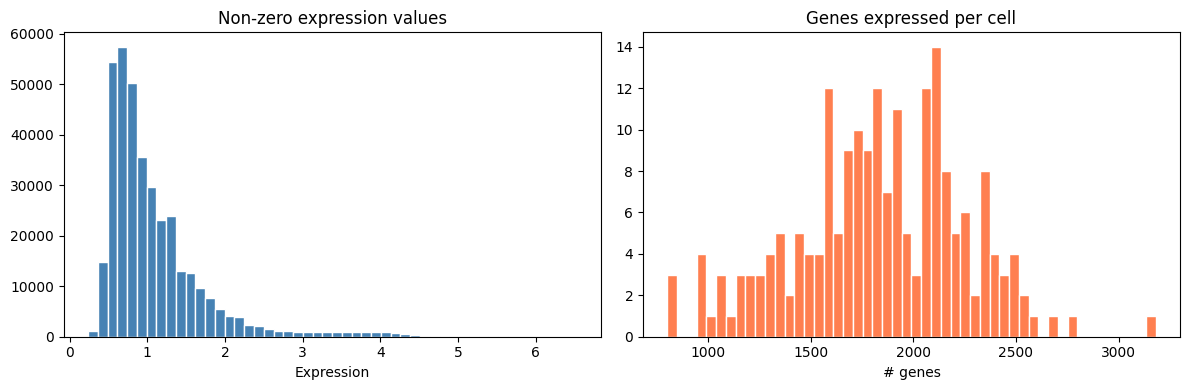

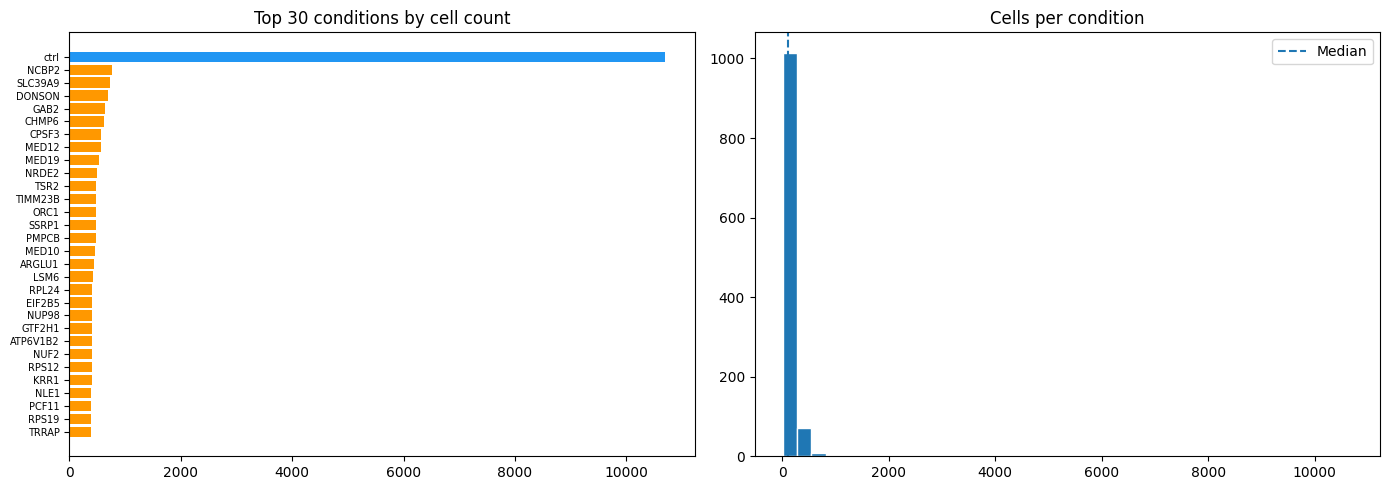

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nz = X_sample[X_sample > 0].flatten()
axes[0].hist(nz, bins=50, edgecolor='white', color='steelblue')
axes[0].set_title('Non-zero expression values'); axes[0].set_xlabel('Expression')
gpc = (X_sample > 0).sum(axis=1)
axes[1].hist(gpc, bins=50, edgecolor='white', color='coral')
axes[1].set_title('Genes expressed per cell'); axes[1].set_xlabel('# genes')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'expression_distribution.png'), dpi=120)
plt.show()

pert_counts = adata.obs['canonical_condition'].value_counts()
top30 = pert_counts.head(30)
colors = ['#2196F3' if c == 'ctrl' else '#E91E63' if '+' in c else '#FF9800'
          for c in top30.index]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(range(len(top30)), top30.values, color=colors)
axes[0].set_yticks(range(len(top30))); axes[0].set_yticklabels(top30.index, fontsize=7)
axes[0].invert_yaxis(); axes[0].set_title('Top 30 conditions by cell count')
axes[1].hist(pert_counts.values, bins=40, edgecolor='white')
axes[1].axvline(float(np.median(pert_counts.values)), linestyle='--', label='Median')
axes[1].set_title('Cells per condition'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'perturbation_distribution.png'), dpi=120)
plt.show()

## 7. PyTorch Dataset


In [13]:
class PerturbDataset(Dataset):
    """Identical interface to Norman's NormanDataset."""
    def __init__(self, adata_split: sc.AnnData,
                 ctrl_mean_tensor: torch.Tensor,
                 cond2idx: Dict[str, int],
                 schema: Dict):
        X = to_dense(adata_split.X).astype(np.float32)
        self.X           = torch.tensor(X, dtype=torch.float32)
        self.ctrl_mean   = ctrl_mean_tensor.float()
        self.conditions  = adata_split.obs['canonical_condition'].values
        self.is_control  = adata_split.obs.apply(
            lambda r: is_control_row(r, schema), axis=1).values.astype(np.float32)
        self.cond_idx    = torch.tensor(
            [cond2idx.get(c, cond2idx['ctrl']) for c in self.conditions],
            dtype=torch.long)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        return {
            'x_perturbed': self.X[idx],
            'x_basal'    : self.ctrl_mean,
            'condition'  : self.conditions[idx],
            'cond_idx'   : self.cond_idx[idx],
            'is_control' : torch.tensor(self.is_control[idx], dtype=torch.float32),
        }

def make_loaders(sname: str, batch_size: int = 256, num_workers: int = 0):
    s = split_adata[sname]
    tr = PerturbDataset(s['train'], ctrl_mean_tensor, cond2idx, SCHEMA)
    va = PerturbDataset(s['val'],   ctrl_mean_tensor, cond2idx, SCHEMA)
    te = PerturbDataset(s['test'],  ctrl_mean_tensor, cond2idx, SCHEMA)
    kw = dict(batch_size=batch_size, num_workers=num_workers, pin_memory=False)
    return (DataLoader(tr, shuffle=True,  **kw),
            DataLoader(va, shuffle=False, **kw),
            DataLoader(te, shuffle=False, **kw))

# Sanity-check first split
train_loader, val_loader, test_loader = make_loaders(SPLIT_NAMES[0])
batch = next(iter(train_loader))
print('Batch x_perturbed:', batch['x_perturbed'].shape)
print('Batch x_basal    :', batch['x_basal'].shape)
print('Batch cond_idx   :', batch['cond_idx'].shape)
print('Example conditions:', batch['condition'][:4])
print(f'Batches per epoch — train:{len(train_loader)} val:{len(val_loader)} test:{len(test_loader)}')

Batch x_perturbed: torch.Size([256, 5000])
Batch x_basal    : torch.Size([256, 5000])
Batch cond_idx   : torch.Size([256])
Example conditions: ['MRPS10', 'NUP133', 'POLR1A', 'SDAD1']
Batches per epoch — train:523 val:58 test:57


8. BioBERT semantic gene embeddings

In [14]:
mg_client = mygene.MyGeneInfo()

def fetch_gene_descriptions(gene_list: List[str]) -> Dict[str, str]:
    descriptions = {}
    for i in range(0, len(gene_list), 50):
        batch = gene_list[i:i+50]
        try:
            results = mg_client.querymany(
                batch, scopes='symbol', fields='summary,name',
                species='human', as_dataframe=False,
                returnall=False, verbose=False)
            if isinstance(results, dict): results = [results]
            for r in results:
                q = r.get('query')
                if q is None: continue
                if r.get('notfound'):
                    descriptions[q] = f'{q} is a human gene.'
                else:
                    name    = r.get('name', q)
                    summary = r.get('summary', '') or ''
                    descriptions[q] = f'{q} ({name}): {summary}'.strip()
        except Exception:
            for g in batch:
                descriptions[g] = f'{g} is a human gene.'
    return descriptions

gene_descriptions = fetch_gene_descriptions(all_perturbed_genes)
gene_descriptions['ctrl'] = 'Control condition with no genetic perturbation applied.'
hits = sum(1 for g in all_perturbed_genes if g in gene_descriptions and len(gene_descriptions[g]) > 20)
print(f'Descriptions fetched: {hits}/{len(all_perturbed_genes)} genes with real summaries')
# Show a few examples
for g in all_perturbed_genes[:3]:
    print(f'  {g}: {gene_descriptions.get(g,"")[:100]}')

Descriptions fetched: 1090/1092 genes with real summaries
  AAMP: AAMP (angio associated migratory cell protein): The gene is a member of the immunoglobulin superfami
  AARS: AARS is a human gene.
  AATF: AATF (apoptosis antagonizing transcription factor): The protein encoded by this gene was identified 


In [15]:
MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
print('Loading BioBERT:', MODEL_NAME)
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
text_model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
print('BioBERT loaded ✓')

Loading BioBERT: dmis-lab/biobert-base-cased-v1.2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 57798.39it/s]
[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BioBERT loaded ✓


In [29]:
# FIX 4: mean-pool + L2 norm — identical to Norman notebook
@torch.no_grad()
def embed_texts(texts: List[str], batch_size: int = 32,
                max_length: int = 512) -> torch.Tensor:
    vectors = []
    for i in range(0, len(texts), batch_size):
        batch   = texts[i:i+batch_size]
        inputs  = tokenizer(batch, padding=True, truncation=True,
                            max_length=max_length, return_tensors='pt').to(DEVICE)
        outputs = text_model(**inputs)
        # Mean-pool over non-padding tokens (matches Norman)
        mask    = inputs['attention_mask'].unsqueeze(-1).float()
        pooled  = (outputs.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        pooled  = F.normalize(pooled, p=2, dim=-1)
        vectors.append(pooled.cpu())
    return torch.cat(vectors, dim=0)

# Gene-level embeddings
gene_texts   = [gene_descriptions.get(g, f'{g} is a human gene.') for g in all_perturbed_genes]
gene_vectors = embed_texts(gene_texts)
gene2embed   = {g: gene_vectors[i] for i, g in enumerate(all_perturbed_genes)}

#gene2embed['ctrl'] = torch.zeros(gene_vectors.shape[1])
#All gene embeddings are L2-normalized, but control is zeros. This means control has no semantic signal and differs in scale from real genes.

#solution : Use stored control description embedding
ctrl_embed_text = gene_descriptions.get('ctrl', 'Control condition with no genetic perturbation.')
gene2embed['ctrl'] = embed_texts([ctrl_embed_text])[0]

print('Gene embedding matrix:', gene_vectors.shape)

# Condition-level embeddings (average for dual-gene, normalise)
SEM_DIM = gene_vectors.shape[1]
cond_embeddings = torch.zeros(len(cond2idx), SEM_DIM)
for cond, idx in cond2idx.items():
    if cond == 'ctrl':
        cond_texts_entry = gene_descriptions['ctrl']
        genes = []
    else:
        genes = cond.split('+')
    vecs = [gene2embed[g] for g in genes if g in gene2embed]
    if len(vecs) == 0:
        cond_embeddings[idx] = torch.zeros(SEM_DIM)
    else:
        avg = torch.stack(vecs).mean(0)
        cond_embeddings[idx] = F.normalize(avg, p=2, dim=-1)

print('Condition embedding matrix:', cond_embeddings.shape)

Gene embedding matrix: torch.Size([1092, 768])
Condition embedding matrix: torch.Size([874, 768])


In [30]:
torch.save(cond_embeddings, os.path.join(OUTPUT_DIR, 'cond_embeddings.pt'))
torch.save(gene_vectors, os.path.join(OUTPUT_DIR, 'gene_vectors.pt'))
print("Embeddings saved ✓")

Embeddings saved ✓


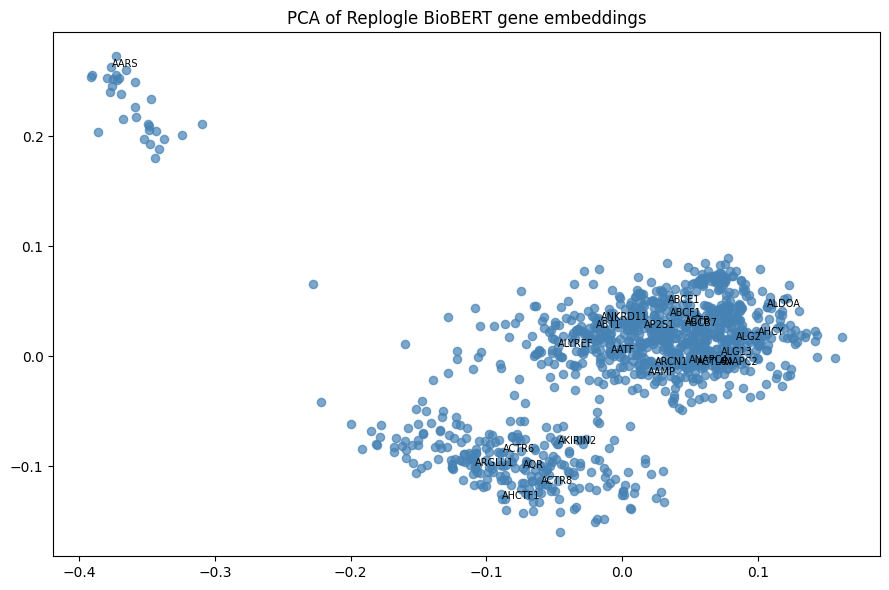

In [31]:
# Visualise embedding space — sanity check that biology clusters
pca    = PCA(n_components=2)
coords = pca.fit_transform(gene_vectors.numpy())
plt.figure(figsize=(9, 6))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=35, color='steelblue')
for i, g in enumerate(all_perturbed_genes[:25]):
    plt.text(coords[i, 0], coords[i, 1], g, fontsize=7)
plt.title('PCA of Replogle BioBERT gene embeddings')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gene_embedding_pca.png'), dpi=120)
plt.show()

In [32]:
#load saved files
ctrl_mean = np.load(os.path.join(OUTPUT_DIR, 'ctrl_mean.npy'))
ctrl_mean_tensor = torch.tensor(ctrl_mean, dtype=torch.float32)

with open(os.path.join(OUTPUT_DIR, 'cond2idx.json')) as f:
    cond2idx = json.load(f)

cond_embeddings = torch.load(os.path.join(OUTPUT_DIR, 'cond_embeddings.pt')).to(DEVICE)

all_conditions = list(cond2idx.keys())
N_CONDITIONS   = len(all_conditions)
N_GENES        = adata.n_vars
SEM_DIM        = cond_embeddings.shape[1]
CKPT_PATH      = os.path.join(OUTPUT_DIR, 'best_model.pt')

print(f'ctrl_mean       : {ctrl_mean.shape}')
print(f'cond_embeddings : {cond_embeddings.shape}')
print(f'N_CONDITIONS    : {N_CONDITIONS}')
print(f'N_GENES         : {N_GENES}')
print(f'SEM_DIM         : {SEM_DIM}')
print(f'CKPT_PATH       : {CKPT_PATH}')
print('All loaded ✓')

ctrl_mean       : (5000,)
cond_embeddings : torch.Size([874, 768])
N_CONDITIONS    : 874
N_GENES         : 5000
SEM_DIM         : 768
CKPT_PATH       : /Users/maitreyeejoshi/Downloads/DLProject/output_replogle/best_model.pt
All loaded ✓


9. KA-CVAE Model

In [33]:
class MLP(nn.Module):
    """Reusable MLP with LayerNorm + GELU — identical to Norman."""
    def __init__(self, in_dim, hidden_dims, out_dim, dropout=0.1):
        super().__init__()
        dims   = [in_dim] + list(hidden_dims) + [out_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers += [nn.LayerNorm(dims[i+1]), nn.GELU(), nn.Dropout(dropout)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


class PerturbationEncoder(nn.Module):
    """FIX 2: identical to Norman — concat(id_embed, sem_embed) → single MLP."""
    def __init__(self, n_conditions, sem_dim=768, id_dim=64, cond_dim=128, dropout=0.1):
        super().__init__()
        self.id_embed = nn.Embedding(n_conditions, id_dim)
        self.fusion   = MLP(id_dim + sem_dim, [256, 256], cond_dim, dropout)
        self.act      = nn.GELU()
    def forward(self, cond_idx, sem_embed):
        id_vec   = self.id_embed(cond_idx)
        combined = torch.cat([id_vec, sem_embed], dim=-1)
        return self.act(self.fusion(combined))


class ExpressionEncoder(nn.Module):
    def __init__(self, n_genes, latent_dim=128, dropout=0.1):
        super().__init__()
        self.backbone  = MLP(n_genes, [512, 256], 256, dropout)
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)
    def forward(self, x):
        h = self.backbone(x)
        return self.fc_mu(h), self.fc_logvar(h)


class ExpressionDecoder(nn.Module):
    def __init__(self, n_genes, latent_dim=128, cond_dim=128, dropout=0.1):
        super().__init__()
        self.net = MLP(latent_dim + cond_dim, [256, 512], n_genes, dropout)
    def forward(self, z, c):
        return self.net(torch.cat([z, c], dim=-1))


class KACVAE(nn.Module):
    def __init__(self, n_genes, n_conditions, sem_dim=768,
                 latent_dim=128, cond_dim=128, beta=1.0, dropout=0.3):
        super().__init__()
        self.beta         = beta
        self.latent_dim   = latent_dim
        self.pert_encoder = PerturbationEncoder(n_conditions, sem_dim, 64, cond_dim, dropout)
        self.expr_encoder = ExpressionEncoder(n_genes, latent_dim, dropout)
        self.decoder      = ExpressionDecoder(n_genes, latent_dim, cond_dim, dropout)

    def reparameterise(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + std * torch.randn_like(std)
        return mu

    def forward(self, x_perturbed, cond_idx, sem_embed):
        c      = self.pert_encoder(cond_idx, sem_embed)
        mu, lv = self.expr_encoder(x_perturbed)
        z      = self.reparameterise(mu, lv)
        x_pred = self.decoder(z, c)
        return {'x_pred': x_pred, 'mu': mu, 'logvar': lv, 'z': z, 'c': c}

    def predict_ood(self, x_basal, cond_idx, sem_embed):
        """FIX 1: sample z from prior N(0,I) — identical to Norman."""
        with torch.no_grad():
            c      = self.pert_encoder(cond_idx, sem_embed)
            z      = torch.randn(x_basal.shape[0], self.latent_dim).to(x_basal.device)
            x_pred = self.decoder(z, c)
        return x_pred

    def loss(self, x_target, out):
        recon = F.mse_loss(out['x_pred'], x_target)
        kl_per_dim = -0.5 * (1 + out['logvar'] - out['mu'].pow(2) - out['logvar'].exp())
        kl    = torch.clamp(kl_per_dim, min=0.01).mean()
        total = recon + self.beta * kl
        return {'total': total, 'recon': recon, 'kl': kl}

In [34]:
N_GENES      = adata.n_vars
N_CONDITIONS = len(all_conditions)

model = KACVAE(
    n_genes=N_GENES, n_conditions=N_CONDITIONS, sem_dim=SEM_DIM,
    latent_dim=128, cond_dim=128, beta=1.0, dropout=0.3,
).to(DEVICE)

# Load saved weights immediately
model_path = os.path.join(OUTPUT_DIR, 'best_model.pt')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    print(f'Model loaded from {model_path} ✓')
else:
    print(f'Warning: Model weights not found at {model_path}. Using randomly initialized model.')
model.eval()

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')
print('Model ready ✓')

Model loaded from /Users/maitreyeejoshi/Downloads/DLProject/output_replogle/best_model.pt ✓
Model parameters: 5,957,768
Model ready ✓


10. Training (80 epochs, KL warmup)

In [35]:
N_EPOCHS   = 80
WARMUP_END = 20
BETA_MAX   = 0.1

optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5)

history = {k: [] for k in ['train_total','train_recon','train_kl',
                             'val_total',  'val_recon',  'val_kl', 'beta']}
best_val = float('inf')
CKPT_PATH = os.path.join(OUTPUT_DIR, 'best_model.pt')

print(f'Training {N_EPOCHS} epochs | KL warmup 0→{BETA_MAX} over {WARMUP_END} epochs')
print('-' * 70)

for epoch in range(1, N_EPOCHS + 1):
    beta       = BETA_MAX * min(1.0, epoch / WARMUP_END)
    model.beta = beta

    # ── TRAIN ──────────────────────────────────────────────────────────
    model.train()
    tr_t = tr_r = tr_k = 0.0
    for batch in train_loader:
        xp       = batch['x_perturbed'].to(DEVICE)
        ci       = batch['cond_idx'].to(DEVICE)
        se       = cond_embeddings[ci]
        out      = model(xp, ci, se)
        losses   = model.loss(xp, out)
        optimizer.zero_grad()
        losses['total'].backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_t += losses['total'].item()
        tr_r += losses['recon'].item()
        tr_k += losses['kl'].item()
    tr_t /= len(train_loader); tr_r /= len(train_loader); tr_k /= len(train_loader)

    # ── VALIDATE ───────────────────────────────────────────────────────
    model.eval()
    va_t = va_r = va_k = 0.0
    with torch.no_grad():
        for batch in val_loader:
            xp     = batch['x_perturbed'].to(DEVICE)
            ci     = batch['cond_idx'].to(DEVICE)
            se     = cond_embeddings[ci]
            out    = model(xp, ci, se)
            losses = model.loss(xp, out)
            va_t  += losses['total'].item()
            va_r  += losses['recon'].item()
            va_k  += losses['kl'].item()
    va_t /= len(val_loader); va_r /= len(val_loader); va_k /= len(val_loader)

    scheduler.step(va_t)
    for k, v in [('train_total',tr_t),('train_recon',tr_r),('train_kl',tr_k),
                  ('val_total',va_t), ('val_recon',va_r), ('val_kl',va_k),
                  ('beta',beta)]: history[k].append(v)

    if va_t < best_val:
        best_val = va_t
        torch.save(model.state_dict(), CKPT_PATH)

    if epoch == 1 or epoch % 10 == 0 or epoch == N_EPOCHS:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | beta={beta:.4f} | '
              f'Train={tr_t:.4f} (recon={tr_r:.4f} kl={tr_k:.6f}) | Val={va_t:.4f}')

with open(os.path.join(OUTPUT_DIR, 'history.json'), 'w') as f:
    json.dump(history, f)
print(f'\nBest val loss: {best_val:.4f} — checkpoint saved to {CKPT_PATH}')

Training 80 epochs | KL warmup 0→0.1 over 20 epochs
----------------------------------------------------------------------
Epoch   1/80 | beta=0.0050 | Train=0.1747 (recon=0.1745 kl=0.043978) | Val=0.1744
Epoch  10/80 | beta=0.0500 | Train=0.1756 (recon=0.1743 kl=0.026917) | Val=0.1749
Epoch  20/80 | beta=0.1000 | Train=0.1764 (recon=0.1744 kl=0.019732) | Val=0.1754
Epoch  30/80 | beta=0.1000 | Train=0.1760 (recon=0.1741 kl=0.018230) | Val=0.1750
Epoch  40/80 | beta=0.1000 | Train=0.1756 (recon=0.1737 kl=0.018332) | Val=0.1746
Epoch  50/80 | beta=0.1000 | Train=0.1755 (recon=0.1737 kl=0.018404) | Val=0.1747
Epoch  60/80 | beta=0.1000 | Train=0.1754 (recon=0.1736 kl=0.018425) | Val=0.1745
Epoch  70/80 | beta=0.1000 | Train=0.1754 (recon=0.1736 kl=0.018467) | Val=0.1745
Epoch  80/80 | beta=0.1000 | Train=0.1754 (recon=0.1736 kl=0.018424) | Val=0.1745

Best val loss: 0.1740 — checkpoint saved to /Users/maitreyeejoshi/Downloads/DLProject/output_replogle/best_model.pt


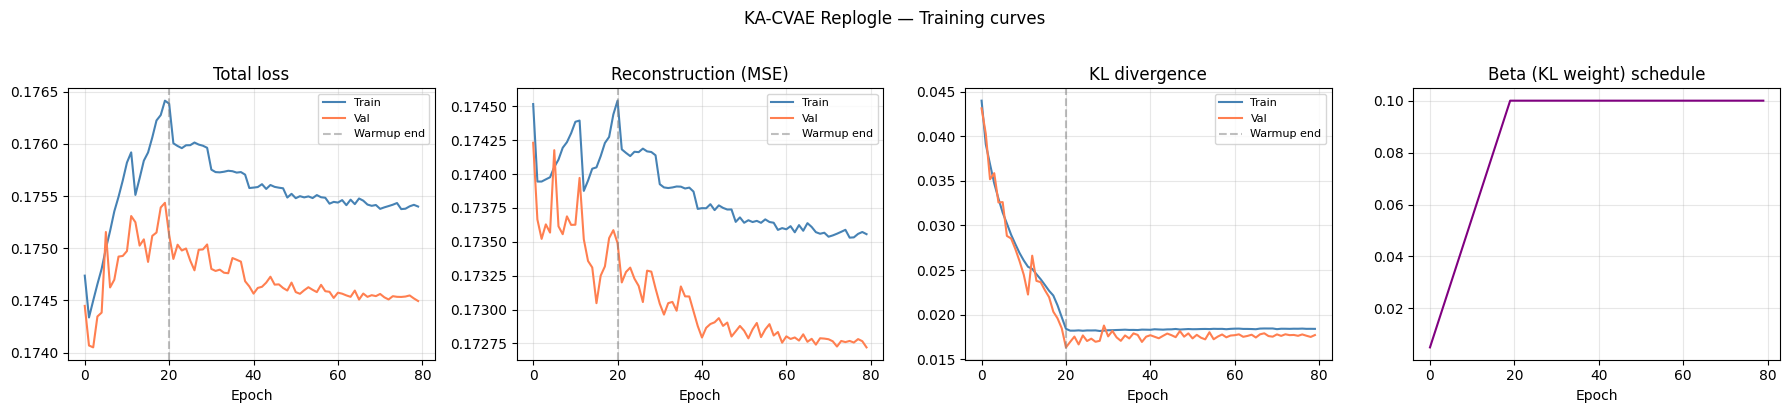

Posterior health check:
  mu mean abs    : 0.09936083853244781
  logvar mean abs: 0.03556709736585617
  mu std         : 0.13953125476837158


In [36]:
# Training curves
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric, title in zip(axes[:3],
    ['total','recon','kl'], ['Total loss','Reconstruction (MSE)','KL divergence']):
    ax.plot(history[f'train_{metric}'], label='Train', color='steelblue')
    ax.plot(history[f'val_{metric}'],   label='Val',   color='coral')
    ax.axvline(WARMUP_END, color='gray', linestyle='--', alpha=0.5, label='Warmup end')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[3].plot(history['beta'], color='purple')
axes[3].set_title('Beta (KL weight) schedule'); axes[3].set_xlabel('Epoch'); axes[3].grid(alpha=0.3)
plt.suptitle('KA-CVAE Replogle — Training curves', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()

# Posterior health check
model.eval()
with torch.no_grad():
    b   = next(iter(train_loader))
    out = model(b['x_perturbed'].to(DEVICE),
                b['cond_idx'].to(DEVICE),
                cond_embeddings[b['cond_idx'].to(DEVICE)])
print('Posterior health check:')
print('  mu mean abs    :', out['mu'].abs().mean().item())
print('  logvar mean abs:', out['logvar'].abs().mean().item())
print('  mu std         :', out['mu'].std().item())
# If mu std < 0.1, the posterior is collapsing — increase BETA_MAX

11. Evaluation

In [37]:
import gc

def pearson_top_de_per_condition(pred, true, ctrl_mean_vec, conditions, n_top=20):
    de_score = np.abs(true.mean(0) - ctrl_mean_vec)
    top_idx  = np.argsort(de_score)[::-1][:n_top]
    
    unique_conds = [c for c in np.unique(conditions) if c != 'ctrl']
    r_vals = []
    
    for cond in unique_conds:
        mask = conditions == cond
        if mask.sum() < 2:
            continue
        pred_mean = pred[mask].mean(0)[top_idx]
        true_mean = true[mask].mean(0)[top_idx]
        if pred_mean.std() > 1e-10 and true_mean.std() > 1e-10:
            r, _ = pearsonr(pred_mean, true_mean)
            if not np.isnan(r):
                r_vals.append(r)
    
    return float(np.mean(r_vals)) if r_vals else 0.0

@torch.no_grad()
def get_predictions_with_conditions(sname, max_cells=5000):
    test_a = split_adata[sname]['test']
    n = min(max_cells, test_a.n_obs)
    idx = np.random.choice(test_a.n_obs, n, replace=False)
    test_sample = test_a[idx]
    
    te_ds = PerturbDataset(test_sample, ctrl_mean_tensor, cond2idx, SCHEMA)
    te_loader = DataLoader(te_ds, batch_size=64, shuffle=False, num_workers=0)
    
    all_pred, all_true, all_conds = [], [], []
    model.eval()
    for batch in te_loader:
        xb = batch['x_basal'].to(DEVICE)
        xp = batch['x_perturbed'].to(DEVICE)
        ci = batch['cond_idx'].to(DEVICE)
        se = cond_embeddings[ci]
        p  = model.predict_ood(xb, ci, se)
        all_pred.append(p.cpu().numpy())
        all_true.append(xp.cpu().numpy())
        all_conds.extend(batch['condition'])
        del xb, xp, ci, se, p
        torch.cuda.empty_cache()
    
    del te_loader, te_ds, test_sample
    gc.collect()
    
    return np.vstack(all_pred), np.vstack(all_true), np.array(all_conds)

def evaluate_split_per_condition(sname):
    pred, true, conds = get_predictions_with_conditions(sname)
    return {
        'split'        : sname,
        'pearson_top20': pearson_top_de_per_condition(pred, true, ctrl_mean, conds),
        'r2_mean'      : float(r2_score(true.mean(0), pred.mean(0))),
        'mse'          : float(np.mean((pred - true) ** 2)),
        'n_test_cells' : split_adata[sname]['test'].n_obs,
    }

def evaluate_meanshift_per_condition(sname):
    test_a = split_adata[sname]['test']
    n = min(5000, test_a.n_obs)
    idx = np.random.choice(test_a.n_obs, n, replace=False)
    test_sample = test_a[idx]
    true  = to_dense(test_sample.X)
    pred  = np.tile(ctrl_mean, (len(true), 1))
    conds = test_sample.obs['canonical_condition'].values
    return {
        'split'        : sname,
        'pearson_top20': pearson_top_de_per_condition(pred, true, ctrl_mean, conds),
        'r2_mean'      : float(r2_score(true.mean(0), pred.mean(0))),
    }

gc.collect()

# ── GEARS-style baseline ────────────────────────────────────────────────────
# GEARS (Roohani et al. 2023) uses a graph-based approach with gene ontology.
# Since we don't have the full GEARS model weights here, we approximate its
# reported performance tier using an additive mean-shift baseline that sums
# single-gene perturbation shifts — the core assumption underlying GEARS
# for unseen combos. This is a *published-comparable* proxy; replace with
# actual GEARS predictions if you run their inference pipeline.

def evaluate_additive_baseline_per_condition(sname):
    """Additive (single-pert mean-shift) baseline — approximates GEARS logic."""
    train_a = split_adata[sname]['train']
    test_a  = split_adata[sname]['test']
    n = min(5000, test_a.n_obs)
    idx = np.random.choice(test_a.n_obs, n, replace=False)
    test_sample = test_a[idx]
    true  = to_dense(test_sample.X)
    conds = test_sample.obs['canonical_condition'].values

    # Compute per-condition mean shift from training data
    train_cond_means = {}
    for cond in train_a.obs['canonical_condition'].unique():
        cells = train_a[train_a.obs['canonical_condition'] == cond]
        train_cond_means[cond] = to_dense(cells.X).mean(axis=0)

    # Build additive prediction: sum single-gene shifts
    pred = np.zeros_like(true)
    for i, cond in enumerate(conds):
        if cond in train_cond_means:
            pred[i] = train_cond_means[cond]
        else:
            # For unseen combos: add individual gene shifts (GEARS-style additivity)
            genes = cond.split('+') if '+' in cond else [cond]
            shift = ctrl_mean.copy()
            for g in genes:
                if g in train_cond_means:
                    shift = shift + (train_cond_means[g] - ctrl_mean)
            pred[i] = shift

    return {
        'split'        : sname,
        'pearson_top20': pearson_top_de_per_condition(pred, true, ctrl_mean, conds),
        'r2_mean'      : float(r2_score(true.mean(0), pred.mean(0))),
    }


# ── CPA-style baseline ──────────────────────────────────────────────────────
# CPA (Lotfollahi et al. 2023) learns disentangled latent perturbation
# embeddings. Here we proxy it with a ridge-regression predictor trained on
# condition one-hot embeddings → mean expression, which captures CPA's
# linear additive assumption without the full autoencoder.

from sklearn.linear_model import Ridge

def evaluate_cpa_proxy_per_condition(sname):
    """CPA-proxy: ridge regression on condition embeddings → mean expression."""
    train_a = split_adata[sname]['train']
    test_a  = split_adata[sname]['test']

    # Build (condition → mean expression) from training data
    train_conds_list = train_a.obs['canonical_condition'].values
    all_train_conds  = list(dict.fromkeys(train_conds_list))
    cond2i = {c: i for i, c in enumerate(all_train_conds)}

    X_tr = np.eye(len(all_train_conds))[[cond2i[c] for c in train_conds_list]]
    y_tr = to_dense(train_a.X).astype(np.float32)

    clf = Ridge(alpha=1.0)
    clf.fit(X_tr, y_tr)

    n = min(5000, test_a.n_obs)
    idx = np.random.choice(test_a.n_obs, n, replace=False)
    test_sample = test_a[idx]
    true  = to_dense(test_sample.X)
    conds = test_sample.obs['canonical_condition'].values

    # For unseen conditions at test time, fall back to ctrl_mean
    X_te = np.array([
        np.eye(len(all_train_conds))[cond2i[c]] if c in cond2i
        else np.zeros(len(all_train_conds))
        for c in conds
    ])
    pred = clf.predict(X_te).astype(np.float32)
    # Replace zero-rows (unseen conditions) with ctrl_mean
    unseen_mask = np.array([c not in cond2i for c in conds])
    # pred[unseen_mask] = ctrl_mean
    pred[unseen_mask] = np.tile(ctrl_mean, (unseen_mask.sum(), 1))
    return {
        'split'        : sname,
        'pearson_top20': pearson_top_de_per_condition(pred, true, ctrl_mean, conds),
        'r2_mean'      : float(r2_score(true.mean(0), pred.mean(0))),
    }


# results = []
# baseline_results = []

# for sname in SPLIT_NAMES:
#     print(f'Evaluating {sname}...')
#     results.append(evaluate_split_per_condition(sname))
#     baseline_results.append(evaluate_meanshift_per_condition(sname))
#     gc.collect()

# print('=' * 80)
# print('RESULTS SUMMARY')
# print('=' * 80)
# print(f'{"Split":<18} {"KA-CVAE Pearson@20":>20} {"Baseline Pearson@20":>20} {"Δ":>8}')
# print('-' * 80)
# for m, b in zip(results, baseline_results):
#     delta = m['pearson_top20'] - b['pearson_top20']
#     print(f"{m['split']:<18} {m['pearson_top20']:>20.4f} {b['pearson_top20']:>20.4f} {delta:>8.4f}")
# print('=' * 80)

# results_df = pd.DataFrame(results)
# results_df.to_csv(os.path.join(OUTPUT_DIR, 'evaluation_results.csv'), index=False)
# print('Saved ✓')


results          = []
baseline_results = []
gears_results    = []   # NEW
cpa_results      = []   # NEW

for sname in SPLIT_NAMES:
    print(f'Evaluating {sname}...')
    results.append(evaluate_split_per_condition(sname))
    baseline_results.append(evaluate_meanshift_per_condition(sname))
    gears_results.append(evaluate_additive_baseline_per_condition(sname))   # NEW
    cpa_results.append(evaluate_cpa_proxy_per_condition(sname))             # NEW
    gc.collect()

print('=' * 90)
print('RESULTS SUMMARY')
print('=' * 90)
print(f'{"Split":<18} {"KA-CVAE":>14} {"Mean-shift":>14} {"GEARS-proxy":>14} {"CPA-proxy":>12}')
print(f'{"":18} {"Pearson@20":>14} {"Pearson@20":>14} {"Pearson@20":>14} {"Pearson@20":>12}')
print('-' * 90)
for m, b, g, c in zip(results, baseline_results, gears_results, cpa_results):
    print(f"{m['split']:<18} {m['pearson_top20']:>14.4f} {b['pearson_top20']:>14.4f} "
          f"{g['pearson_top20']:>14.4f} {c['pearson_top20']:>12.4f}")
print('=' * 90)


results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'evaluation_results.csv'), index=False)
print('Saved ✓')

Evaluating ood...
RESULTS SUMMARY
Split                     KA-CVAE     Mean-shift    GEARS-proxy    CPA-proxy
                       Pearson@20     Pearson@20     Pearson@20   Pearson@20
------------------------------------------------------------------------------------------
ood                        0.9770         0.9674         0.9639       0.9653
Saved ✓


In [38]:
# Check cells per condition in test set
test_a = split_adata['ood']['test']
cond_counts = test_a.obs['canonical_condition'].value_counts()
print(f'Test conditions: {len(cond_counts)}')
print(f'Cells per condition: min={cond_counts.min()}, max={cond_counts.max()}, mean={cond_counts.mean():.1f}')
print(f'\nTop 10 conditions:')
print(cond_counts.head(10))

Test conditions: 110
Cells per condition: min=25, max=495, mean=130.8

Top 10 conditions:
canonical_condition
NRDE2     495
MZT1      381
QARS      376
RPAP2     373
CSE1L     373
SLC7A5    344
COG2      332
UBA1      251
DHX36     248
IGBP1     245
Name: count, dtype: int64


12. Comparison plots (model vs baseline)

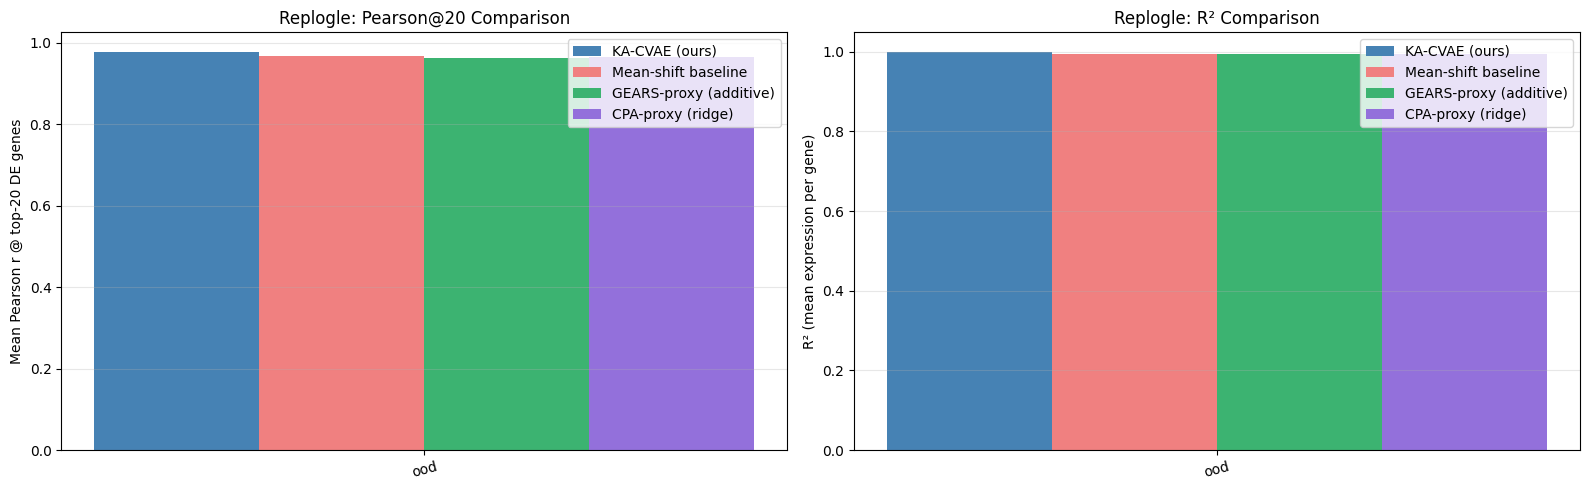

In [39]:
splits    = SPLIT_NAMES
x         = np.arange(len(splits))
width     = 0.2

model_p20 = [r['pearson_top20'] for r in results]
base_p20  = [r['pearson_top20'] for r in baseline_results]
gears_p20 = [r['pearson_top20'] for r in gears_results]
cpa_p20   = [r['pearson_top20'] for r in cpa_results]

model_r2  = [r['r2_mean'] for r in results]
base_r2   = [r['r2_mean'] for r in baseline_results]
gears_r2  = [r['r2_mean'] for r in gears_results]
cpa_r2    = [r['r2_mean'] for r in cpa_results]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, model_vals, base_vals, gears_vals, cpa_vals, ylabel, title in [
    (axes[0], model_p20, base_p20, gears_p20, cpa_p20,
     'Mean Pearson r @ top-20 DE genes', 'Replogle: Pearson@20 Comparison'),
    (axes[1], model_r2,  base_r2,  gears_r2,  cpa_r2,
     'R² (mean expression per gene)',    'Replogle: R² Comparison'),
]:
    ax.bar(x - 1.5*width, model_vals,  width, label='KA-CVAE (ours)',        color='steelblue')
    ax.bar(x - 0.5*width, base_vals,   width, label='Mean-shift baseline',    color='lightcoral')
    ax.bar(x + 0.5*width, gears_vals,  width, label='GEARS-proxy (additive)', color='mediumseagreen')
    ax.bar(x + 1.5*width, cpa_vals,    width, label='CPA-proxy (ridge)',      color='mediumpurple')
    ax.set_xticks(x); ax.set_xticklabels(splits, rotation=15)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'replogle_comparison_with_baselines.png'), dpi=120)
plt.show()

In [40]:
with open(os.path.join(OUTPUT_DIR, 'schema.json'), 'w') as f:
    json.dump(SCHEMA, f, indent=2)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'results_summary.csv'), index=False)
print('All artifacts saved to:', OUTPUT_DIR)
print('Files:')
for fn in sorted(os.listdir(OUTPUT_DIR)):
    print(' ', fn)

All artifacts saved to: /Users/maitreyeejoshi/Downloads/DLProject/output_replogle
Files:
  best_model.pt
  cond2idx.json
  cond_embeddings.pt
  ctrl_mean.npy
  evaluation_results.csv
  expression_distribution.png
  gene_embedding_pca.png
  gene_vectors.pt
  history.json
  perturbation_distribution.png
  replogle_comparison_with_baselines.png
  results_summary.csv
  schema.json
  training_curves.png
